In [ ]:
# MapAnything - Reconstruction 3D métrique (Meta)

#Modèle universel feed-forward pour la reconstruction 3D à partir d'images.  
#Documentation : [GitHub facebookresearch/map-anything](https://github.com/facebookresearch/map-anything)


## 1. Installation (à exécuter une fois)

Tout se fait **dans le projet** et **dans le venv** : activer le venv en premier, puis télécharger MapAnything dans le projet et installer avec `pip install -e .`.

### Étape 0 : activer le venv (obligatoire)

```powershell
cd C:\Users\mvm\open3d_vision
.\.venv\Scripts\Activate.ps1
```

### Option A : Avec Git (si `git` est reconnu dans PowerShell)

```powershell
# Depuis open3d_vision, venv déjà activé
git clone https://github.com/facebookresearch/map-anything.git
cd map-anything
pip install -e .
cd ..
```

### Option B : Sans Git (PowerShell uniquement)

Télécharger le ZIP **dans le projet** puis installer dans le venv :

```powershell
# Depuis open3d_vision, venv déjà activé
$projet = "C:\Users\mvm\open3d_vision"
$url = "https://github.com/facebookresearch/map-anything/archive/refs/heads/main.zip"
$zip = "$env:TEMP\map-anything.zip"
Invoke-WebRequest -Uri $url -OutFile $zip -UseBasicParsing
Expand-Archive -Path $zip -DestinationPath $env:TEMP -Force
Move-Item -Path "$env:TEMP\map-anything-main" -Destination "$projet\map-anything" -Force
Remove-Item $zip

Set-Location "$projet\map-anything"
pip install -e .
Set-Location $projet
```

### Si Git n’est pas reconnu

Installer [Git pour Windows](https://git-scm.com/download/win), puis **redémarrer PowerShell** et réactiver le venv.

**Prérequis :** PyTorch avec CUDA recommandé. Premier run : téléchargement des poids depuis Hugging Face (`facebook/map-anything` ou `facebook/map-anything-apache` pour licence Apache 2.0).

In [35]:
# S'assurer que Python trouve le module mapanything (dossier map-anything du projet)
import sys
from pathlib import Path

def _add_map_anything_path():
    """Ajoute le chemin du repo map-anything à sys.path si le module n'est pas installé."""
    if "mapanything" in sys.modules:
        return
    # Candidats : racine projet = parent de src/, ou cwd
    racine = Path.cwd() if (Path.cwd() / "map-anything").exists() else Path.cwd().parent
    map_anywhere = racine / "map-anything"
    if map_anywhere.exists() and str(map_anywhere) not in sys.path:
        sys.path.insert(0, str(map_anywhere))
        print(f"MapAnything ajouté au path : {map_anywhere}")

_add_map_anything_path()

In [36]:
# Configuration mémoire (recommandé pour grosses séquences)
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
from pathlib import Path

# Dossier d'images pour la prédiction (valid 0013/001)
IMAGES_PATH = Path(r"C:\Users\mvm\open3d_vision\data\archive\data\valid\0013\001")
IMAGE_PATHS = sorted(IMAGES_PATH.glob("*.png"))
if not IMAGE_PATHS:
    IMAGE_PATHS = str(IMAGES_PATH)
else:
    # Sous-échantillonnage : ~15–20 vues bien réparties améliore souvent la cohérence
    STEP = max(1, len(IMAGE_PATHS) // 20)
    IMAGE_PATHS = IMAGE_PATHS[::STEP]

In [37]:
def load_model(device=None, use_apache=False):
    """Charge le modèle MapAnything depuis Hugging Face (nécessite accès internet au premier run)."""
    from mapanything.models import MapAnything
    name = "facebook/map-anything-apache" if use_apache else "facebook/map-anything"
    model = MapAnything.from_pretrained(name).to(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    return model

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_model(device=device, use_apache=False)
print(f"Modèle chargé sur {device}.")

config.json: 0.00B [00:00, ?B/s]

c:\Users\mvm\open3d_vision\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mvm\.cache\huggingface\hub\models--facebook--map-anything. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading pretrained dinov2_vitg14 from torch hub
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to C:\Users\mvm/.cache\torch\hub\main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitg14/dinov2_vitg14_pretrain.pth" to C:\Users\mvm/.cache\torch\hub\checkpoints\dinov2_vitg14_pretrain.pth


100%|██████████| 4.23G/4.23G [03:20<00:00, 22.7MB/s]


model.safetensors:   0%|          | 0.00/4.91G [00:00<?, ?B/s]

Modèle chargé sur cpu.


In [38]:
def load_views(folder_or_list):
    """Charge et prétraite les images au format attendu par MapAnything."""
    from mapanything.utils.image import load_images
    if isinstance(folder_or_list, list):
        folder_or_list = [str(p) for p in folder_or_list]
    else:
        folder_or_list = str(folder_or_list)
    return load_images(folder_or_list)

views = load_views(IMAGE_PATHS)
print(f"Vues chargées : {len(views)}.")

Vues chargées : 20.


In [39]:
# Inférence (image-only) avec paramètres pour une meilleure qualité
predictions = model.infer(
    views,
    memory_efficient_inference=True,
    minibatch_size=None,
    use_amp=True,
    amp_dtype="bf16",
    apply_mask=True,
    mask_edges=True,
    edge_normal_threshold=8.0,
    edge_depth_threshold=0.05,
    use_multiview_confidence=True,
    apply_confidence_mask=True,
    confidence_percentile=25,
)
print(f"Prédictions : {len(predictions)} vues.")

Non-CUDA device detected. Using conservative default minibatch size of 1 for memory efficient dense prediction head inference.


Checking triangle intersections: 100%|██████████| 1/1 [00:00<00:00, 23.17it/s]


Prédictions : 20 vues.


In [40]:
# Accès aux sorties (une entrée par vue)
for i, pred in enumerate(predictions):
    pts3d = pred["pts3d"]           # points 3D monde (B, H, W, 3)
    depth_z = pred["depth_z"]       # profondeur Z caméra (B, H, W, 1)
    poses = pred["camera_poses"]    # poses cam2world OpenCV (B, 4, 4)
    intrinsics = pred["intrinsics"] # intrinsèques (B, 3, 3)
    mask = pred["mask"]             # masque validité (B, H, W, 1)
    # Exemple : extraire nuage de points pour la vue 0
    if i == 0:
        pts = pts3d[0].cpu().numpy()
        mask_np = mask[0].cpu().numpy().squeeze()
        pts_valid = pts[mask_np > 0]
        print(f"Vue {i}: pts3d shape {pts3d.shape}, points valides {len(pts_valid)}")

Vue 0: pts3d shape torch.Size([1, 518, 518, 3]), points valides 192123


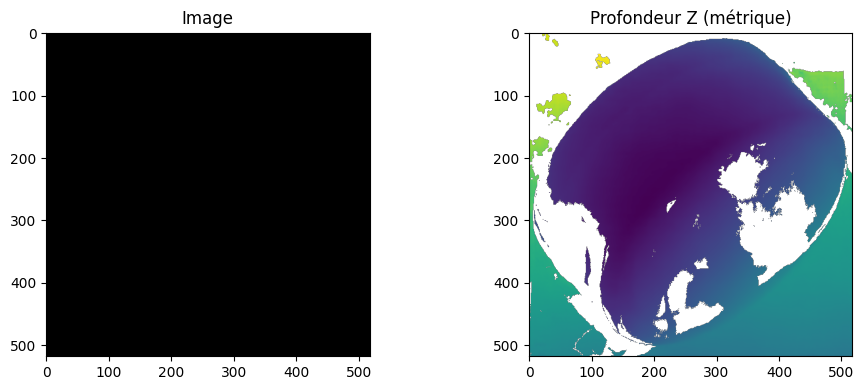

In [41]:
# Visualisation rapide : profondeur de la première vue
import matplotlib.pyplot as plt
import numpy as np

idx = 0
depth = predictions[idx]["depth_z"][0, :, :, 0].cpu().numpy()
mask_viz = predictions[idx]["mask"][0, :, :, 0].cpu().numpy()
depth_masked = np.where(mask_viz > 0, depth, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(predictions[idx]["img_no_norm"][0].cpu().numpy().astype(np.uint8))
ax[0].set_title("Image")
ax[1].imshow(depth_masked, cmap="viridis")
ax[1].set_title("Profondeur Z (métrique)")
plt.tight_layout()
plt.show()

In [42]:
# Nuage de points 3D fusionné, avec filtrage optionnel par confiance
def predictions_to_point_cloud(predictions, min_conf=0.0):
    """Fusionne les pts3d de toutes les vues en un nuage Nx3. min_conf > 0 filtre par confiance."""
    all_pts = []
    for pred in predictions:
        pts = pred["pts3d"][0].cpu().numpy()
        m = pred["mask"][0, :, :, 0].cpu().numpy() > 0
        if min_conf > 0 and "conf" in pred:
            conf = pred["conf"][0].cpu().numpy()
            m = m & (conf >= min_conf)
        all_pts.append(pts[m])
    return np.vstack(all_pts) if all_pts else np.zeros((0, 3))

points_3d = predictions_to_point_cloud(predictions, min_conf=0.0)
print(f"Nuage fusionné : {len(points_3d)} points.")

Nuage fusionné : 3343494 points.


In [45]:
# Visualisation avec Open3D + suppression des outliers
try:
    import open3d as o3d
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d)
    pcd_clean, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    print(f"Après suppression outliers : {len(pcd_clean.points)} points.")
    o3d.visualization.draw_geometries([pcd_clean], window_name="MapAnything - Nuage 3D")
except ImportError:
    print("Open3D non installé : pip install open3d")

Après suppression outliers : 3245854 points.
